In [2]:
from specutils.analysis import correlation
from astropy.modeling import models
from astropy.nddata import StdDevUncertainty
import numpy as np
import astropy.units as u
from specutils import Spectrum1D
import os, sys
from astropy.io import fits
%matplotlib notebook
import matplotlib.pyplot as plt
#from ipywidgets import interact
import warnings
import copy

In [3]:

#np.seterr(under='ignore')
size = 200
spec_axis = np.linspace(4500., 6500., num=size) * u.AA
f1 = np.random.randn(size)*0.5 * u.Jy
f2 = np.random.randn(size)*0.5 * u.Jy
rest_value = 6000. * u.AA
mean1 = 5035. * u.AA
mean2 = 5015. * u.AA
g1 = models.Gaussian1D(amplitude=30 * u.Jy, mean=mean1, stddev=10. * u.AA)
g2 = models.Gaussian1D(amplitude=30 * u.Jy, mean=mean2, stddev=10. * u.AA)
flux1 = f1 + g1(spec_axis)
flux2 = f2 + g2(spec_axis)

uncertainty = StdDevUncertainty(0.2*np.ones(size)*u.Jy)
ospec = Spectrum1D(spectral_axis=spec_axis, flux=flux1, uncertainty=uncertainty, velocity_convention='optical', rest_value=rest_value)
tspec = Spectrum1D(spectral_axis=spec_axis, flux=flux2, uncertainty=uncertainty)
with warnings.catch_warnings():  # Ignore warnings
    warnings.simplefilter('ignore')
    corr, lag = correlation.template_correlate(ospec, tspec)

In [4]:
corr
lag
lag.unit
maxind = np.argmax(corr)
print(lag[maxind])
print(corr[maxind])
print(uncertainty)


1394.9219620149731 km / s
785.4793730095193
StdDevUncertainty([0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
                   0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,

In [16]:
spec_shift= copy.deepcopy(tspec)
tspec.spectral_axis
spec_shift.shift_spectrum_to(radial_velocity = lag[maxind])
spec_shift.spectral_axis


<SpectralAxis 
   (observer to target:
      radial_velocity=1394.9219620149731 km / s
      redshift=0.004663834379143639)
  [4520.98725471, 4531.08437867, 4541.18150263, 4551.2786266 ,
   4561.37575056, 4571.47287452, 4581.56999849, 4591.66712245,
   4601.76424642, 4611.86137038, 4621.95849434, 4632.05561831,
   4642.15274227, 4652.24986623, 4662.3469902 , 4672.44411416,
   4682.54123812, 4692.63836209, 4702.73548605, 4712.83261001,
   4722.92973398, 4733.02685794, 4743.12398191, 4753.22110587,
   4763.31822983, 4773.4153538 , 4783.51247776, 4793.60960172,
   4803.70672569, 4813.80384965, 4823.90097361, 4833.99809758,
   4844.09522154, 4854.19234551, 4864.28946947, 4874.38659343,
   4884.4837174 , 4894.58084136, 4904.67796532, 4914.77508929,
   4924.87221325, 4934.96933721, 4945.06646118, 4955.16358514,
   4965.2607091 , 4975.35783307, 4985.45495703, 4995.552081  ,
   5005.64920496, 5015.74632892, 5025.84345289, 5035.94057685,
   5046.03770081, 5056.13482478, 5066.23194874, 5076.3290

<IPython.core.display.Javascript object>


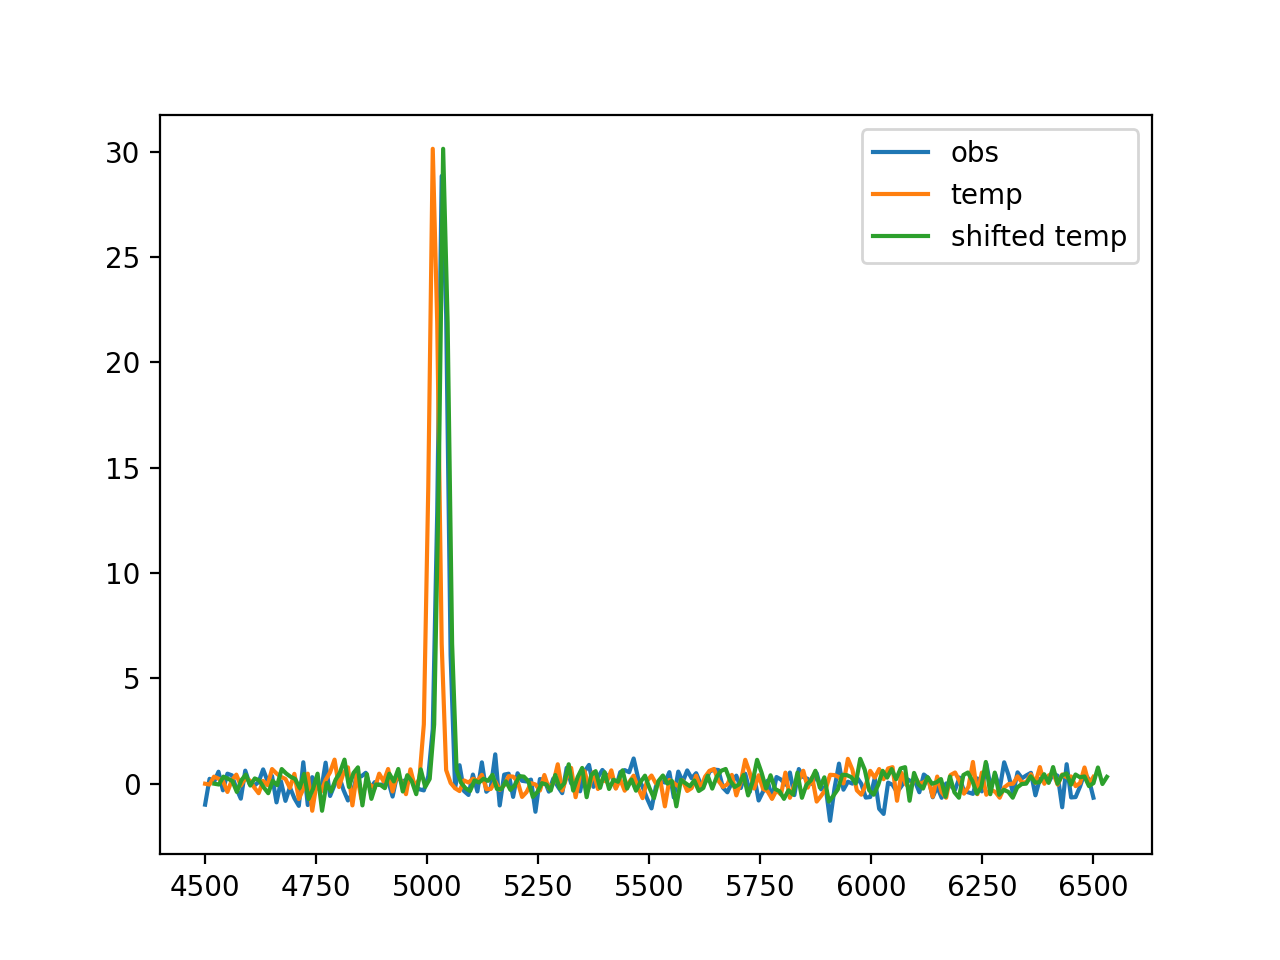

In [18]:
plt.plot(ospec.spectral_axis, ospec.flux, label='obs')
plt.plot(tspec.spectral_axis, tspec.flux, label='temp')
plt.plot(spec_shift.spectral_axis, spec_shift.flux, label='shifted temp')
plt.legend()